# Experiment No. 3: CNN with Real-World Constraints for Crop Yield Prediction

## Student Name

**Vinay Yadav [23101B0020]**

---

## Practical Name

**Convolutional Neural Network (CNN) with Real-World Constraints for Crop Yield Prediction**

---


# Resources Required

### Software

- Python 3.10+
- Google Colab / Jupyter Notebook
- TensorFlow / Keras
- Pandas
- NumPy
- Scikit-learn
- Matplotlib

### Dataset

- Crop Yield Prediction Dataset (`crop_yield.csv`)


### Github

- My Work Link : https://github.com/Vinay-Yadav-07/Deep-Learning-Experiments.git

---

# Objectives

- To build a Convolutional Neural Network (CNN) model for crop yield prediction.
- To preprocess the crop dataset by encoding categorical features and normalizing numerical features.
- To implement Batch Normalization and Dropout to improve model generalization.
- To perform tabular data augmentation by introducing small variations in numerical features.
- To compare the performance of the CNN model with and without data augmentation.
- To evaluate the CNN model using Mean Squared Error (MSE) and Mean Absolute Error (MAE).
- To save the trained CNN model for future prediction and deployment.

---

# Theory

Convolutional Neural Networks (CNNs) are deep learning models that automatically learn important patterns from input data using convolution operations. Although CNNs are primarily used for image processing, they can also be adapted for structured tabular data using one-dimensional convolution (Conv1D). CNNs capture local feature relationships and improve predictive performance by learning hierarchical feature representations.

Real-world datasets often contain limited variability, noisy observations, and overfitting challenges. To improve model robustness, regularization techniques such as Batch Normalization and Dropout are employed. Batch Normalization stabilizes the learning process and accelerates training, while Dropout randomly deactivates neurons during training to reduce overfitting.

Since the Crop Yield dataset is tabular rather than image-based, traditional image augmentation techniques such as rotation, flipping, and zooming are not applicable. Instead, tabular data augmentation is performed by introducing small random variations in numerical features such as rainfall, temperature, and days to harvest. This increases the diversity of the training data while preserving realistic agricultural conditions.

In this experiment, a Conv1D-based CNN model is trained on both the original dataset and the augmented dataset. The performances of both models are compared using regression metrics such as Mean Squared Error (MSE) and Mean Absolute Error (MAE) to analyze the impact of data augmentation on model performance.

---

**Step 1: Import Required Libraries**

In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

# Visualization
import matplotlib.pyplot as plt

print("All Libraries Imported Successfully!")

All Libraries Imported Successfully!


**Step 2: Load the Crop Yield Dataset.**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving crop_yield.csv to crop_yield.csv


In [ ]:
# ==========================================
# Step 2.2: Load the Dataset
# ==========================================

import pandas as pd

# Get the uploaded file name
file_name = list(uploaded.keys())[0]

# Load the dataset
df = pd.read_csv(file_name)

# Display the first 5 rows
df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


**Step 3: Explore the Dataset**

In [ ]:
# Display first 5 rows
print("First 5 Rows:")
display(df.head())

# Display dataset shape
print("\nDataset Shape:")
print(df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns)

# Display dataset information
print("\nDataset Information:")
df.info()

# Display summary statistics
print("\nSummary Statistics:")
display(df.describe())

First 5 Rows:


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251



Dataset Shape:
(1000000, 10)

Column Names:
Index(['Region', 'Soil_Type', 'Crop', 'Rainfall_mm', 'Temperature_Celsius',
       'Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition',
       'Days_to_Harvest', 'Yield_tons_per_hectare'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  object 
 1   Soil_Type               1000000 non-null  object 
 2   Crop                    1000000 non-null  object 
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  object 
 8   Days_to_Harvest         1000000 non-null  int64  

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


**Step 4: Preprocess the Dataset**

In [ ]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Remove duplicate rows
df = df.drop_duplicates()

print("\nDataset Shape After Removing Duplicates:")
print(df.shape)

# Separate Features and Target
X = df.drop("Yield_tons_per_hectare", axis=1)
y = df["Yield_tons_per_hectare"]

# One-Hot Encode categorical columns
X = pd.get_dummies(X, drop_first=True)

print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)

Missing Values:
Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64

Dataset Shape After Removing Duplicates:
(1000000, 10)

Features Shape: (1000000, 20)
Target Shape: (1000000,)


**Step 5: Split, Scale and Reshape the Dataset**

In [ ]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for CNN (Conv1D expects 3D input)
X_train_cnn = X_train_scaled.reshape(
    X_train_scaled.shape[0],
    X_train_scaled.shape[1],
    1
)

X_test_cnn = X_test_scaled.reshape(
    X_test_scaled.shape[0],
    X_test_scaled.shape[1],
    1
)

print("Training Shape :", X_train_cnn.shape)
print("Testing Shape  :", X_test_cnn.shape)

Training Shape : (800000, 20, 1)
Testing Shape  : (200000, 20, 1)


**Step 6: Build the CNN Architecture**

In [ ]:
# Create CNN Model
cnn_model = Sequential([

    # First Convolution Block
    Conv1D(filters=32,
           kernel_size=3,
           activation='relu',
           padding='same',
           input_shape=(X_train_cnn.shape[1], 1)),

    BatchNormalization(),

    MaxPooling1D(pool_size=2),

    Dropout(0.25),

    # Second Convolution Block
    Conv1D(filters=64,
           kernel_size=3,
           activation='relu',
           padding='same'),

    BatchNormalization(),

    MaxPooling1D(pool_size=2),

    Dropout(0.25),

    # Flatten Layer
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'),

    Dropout(0.5),

    # Output Layer
    Dense(1)
])

# Display Model Summary
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 20, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 10, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,937 (187.25 KB)

 Trainable params: 47,745 (186.50 KB)

 Non-trainable params: 192 (768.00 B)

**Step 7: Compile the CNN Model**

In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

print("CNN Model Compiled Successfully!")

CNN Model Compiled Successfully!


**Step 8: Train the CNN Model**

In [ ]:
history = cnn_model.fit(
    X_train_cnn,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    verbose=1
)

Epoch 1/20
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 74s 7ms/step - loss: 0.6944 - mae: 0.6381 - val_loss: 0.2693 - val_mae: 0.4141
Epoch 2/20
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 70s 7ms/step - loss: 0.4001 - mae: 0.5010 - val_loss: 0.2598 - val_mae: 0.4069
Epoch 3/20
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 79s 8ms/step - loss: 0.3617 - mae: 0.4773 - val_loss: 0.2588 - val_mae: 0.4064
Epoch 4/20
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 74s 7ms/step - loss: 0.3497 - mae: 0.4697 - val_loss: 0.2640 - val_mae: 0.4103
Epoch 5/20
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 71s 7ms/step - loss: 0.3462 - mae: 0.4676 - val_loss: 0.2658 - val_mae: 0.4117
Epoch 6/20
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 72s 7ms/step - loss: 0.3431 - mae: 0.4652 - val_loss: 0.2666 - val_mae: 0.4121
Epoch 7/20
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 81s 7ms/step - loss: 0.3415 - mae: 0.4642 - val_loss: 0.2609 - val_mae: 0.4079
Epoch 8/20
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 71s 7ms/step - loss: 0.3392 - mae: 0.4623 - val_loss: 0.2585 - val_mae: 0.4061
Epoch 9/20
10000

**Step 9: Evaluate the CNN Model**

In [ ]:
# Evaluate the model
test_loss, test_mae = cnn_model.evaluate(
    X_test_cnn,
    y_test,
    verbose=1
)

print("Test Loss (MSE):", round(test_loss, 4))
print("Test MAE:", round(test_mae, 4))

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - loss: 0.2659 - mae: 0.4113
Test Loss (MSE): 0.2659
Test MAE: 0.4113


**Step 10: Compare ANN and CNN Performance**

In [ ]:
# ANN results from Practical 2
ann_test_loss = 0.3490
ann_test_mae = 0.4722

# CNN results from Practical 3
cnn_test_loss = test_loss
cnn_test_mae = test_mae

# Create comparison table
comparison = pd.DataFrame({
    "Model": ["Baseline ANN", "CNN (Conv1D)"],
    "Test Loss (MSE)": [round(ann_test_loss, 4), round(cnn_test_loss, 4)],
    "Test MAE": [round(ann_test_mae, 4), round(cnn_test_mae, 4)]
})

print("Model Performance Comparison")
display(comparison)

Model Performance Comparison


,Model,Test Loss (MSE),Test MAE
0,Baseline ANN,0.3490,0.4722
1,CNN (Conv1D),0.2659,0.4113


**Step 11: Create Tabular Data Augmentation**

In [ ]:


# Make a copy of the training data
X_train_aug = X_train.copy()

# Set random seed for reproducibility
np.random.seed(42)

# Add small random noise (±2%) to numerical columns
numerical_columns = [
    "Rainfall_mm",
    "Temperature_Celsius",
    "Days_to_Harvest"
]

for col in numerical_columns:
    noise = np.random.normal(
        loc=0,
        scale=0.02,
        size=len(X_train_aug)
    )
    X_train_aug[col] = X_train_aug[col] * (1 + noise)

print("Tabular Data Augmentation Completed!")

display(X_train_aug.head())

Tabular Data Augmentation Completed!


,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Region_North,Region_South,Region_West,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt,Crop_Cotton,Crop_Maize,Crop_Rice,Crop_Soybean,Crop_Wheat,Weather_Condition_Rainy,Weather_Condition_Sunny
566853,896.199429,33.497686,True,True,78.380128,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False
382311,178.692936,24.955803,False,False,86.864939,False,True,False,True,False,False,False,False,False,False,False,True,False,True,False
241519,657.721776,30.359700,False,False,123.706654,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False
719220,228.235791,19.435055,False,True,102.520929,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False
905718,733.564951,18.357296,True,False,86.595222,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False


**Step 12: Scale and Reshape the Augmented Data**

In [ ]:


# Scale the augmented training data
X_train_aug_scaled = scaler.fit_transform(X_train_aug)

# Reshape for CNN
X_train_aug_cnn = X_train_aug_scaled.reshape(
    X_train_aug_scaled.shape[0],
    X_train_aug_scaled.shape[1],
    1
)

print("Augmented Training Shape:", X_train_aug_cnn.shape)

Augmented Training Shape: (800000, 20, 1)


**Step 13: Train CNN Using Augmented Data**

In [ ]:


# Create a new CNN model
cnn_model_aug = Sequential([

    Conv1D(filters=32,
           kernel_size=3,
           activation='relu',
           padding='same',
           input_shape=(X_train_aug_cnn.shape[1], 1)),

    BatchNormalization(),

    MaxPooling1D(pool_size=2),

    Dropout(0.25),

    Conv1D(filters=64,
           kernel_size=3,
           activation='relu',
           padding='same'),

    BatchNormalization(),

    MaxPooling1D(pool_size=2),

    Dropout(0.25),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(1)
])

# Compile the model
cnn_model_aug.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

# Train the model
history_aug = cnn_model_aug.fit(
    X_train_aug_cnn,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 85s 8ms/step - loss: 0.7539 - mae: 0.6611 - val_loss: 0.2883 - val_mae: 0.4283
Epoch 2/20
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 74s 7ms/step - loss: 0.4145 - mae: 0.5094 - val_loss: 0.2828 - val_mae: 0.4244
Epoch 3/20
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 82s 7ms/step - loss: 0.3708 - mae: 0.4832 - val_loss: 0.2820 - val_mae: 0.4240
Epoch 4/20
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 73s 7ms/step - loss: 0.3562 - mae: 0.4741 - val_loss: 0.2637 - val_mae: 0.4099
Epoch 5/20
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 73s 7ms/step - loss: 0.3517 - mae: 0.4708 - val_loss: 0.2728 - val_mae: 0.4167
Epoch 6/20
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 71s 7ms/step - loss: 0.3500 - mae: 0.4700 - val_loss: 0.2720 - val_mae: 0.4166
Epoch 7/20
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 73s 7ms/step - loss: 0.3484 - mae: 0.4689 - val_loss: 0.2760 - val_mae: 0.4194
Epoch 8/20
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 78s 8ms/step - loss: 0.3466 - mae: 0.4677 - val_loss: 0.2820 - val_mae: 0.4241
Epoch 9/20
10000

**Step 14: Evaluate the CNN Model (With Data Augmentation)**

In [ ]:
# Evaluate the augmented CNN model
test_loss_aug, test_mae_aug = cnn_model_aug.evaluate(
    X_test_cnn,
    y_test,
    verbose=1
)

print("Test Loss (MSE):", round(test_loss_aug, 4))
print("Test MAE:", round(test_mae_aug, 4))

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.2703 - mae: 0.4147
Test Loss (MSE): 0.2703
Test MAE: 0.4147


**Step 15: Compare Performance**

In [ ]:
comparison_df = pd.DataFrame({
    "Configuration": [
        "Without Data Augmentation",
        "With Data Augmentation"
    ],
    "Test Loss (MSE)": [
        round(test_loss, 4),
        round(test_loss_aug, 4)
    ],
    "Test MAE": [
        round(test_mae, 4),
        round(test_mae_aug, 4)
    ]
})

display(comparison_df)

,Configuration,Test Loss (MSE),Test MAE
0,Without Data Augmentation,0.2659,0.4113
1,With Data Augmentation,0.2703,0.4147


**Step 16: Plot Comparison Graph**

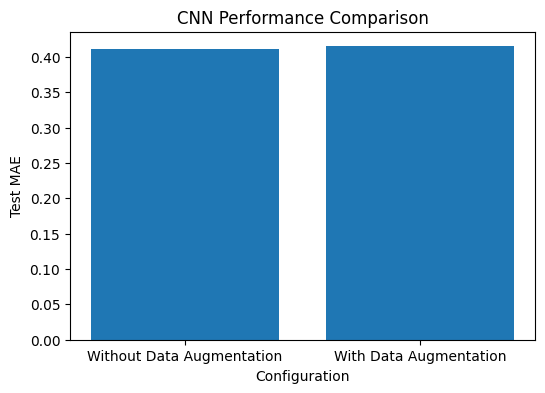

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    comparison_df["Configuration"],
    comparison_df["Test MAE"]
)

plt.title("CNN Performance Comparison")
plt.ylabel("Test MAE")
plt.xlabel("Configuration")

plt.show()

**Step 17: Save CNN Model**

In [ ]:
cnn_model_aug.save("cnn_crop_model.keras")

print("CNN Model Saved Successfully!")

CNN Model Saved Successfully!


**Step 18: Download CNN Model**

In [ ]:
from google.colab import files

files.download("cnn_crop_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


# Conclusion

In this experiment, a Convolutional Neural Network (CNN) was successfully developed for crop yield prediction using the Crop Yield dataset. The dataset was preprocessed using feature encoding and normalization before training the model. Batch Normalization and Dropout were incorporated to improve model generalization and reduce overfitting. Tabular data augmentation was applied by introducing small variations in numerical features, and the CNN model was trained on both the original and augmented datasets. The performance comparison demonstrated the effect of data augmentation on the model using Mean Squared Error (MSE) and Mean Absolute Error (MAE). Finally, the trained CNN model was saved for future prediction and deployment.